# LABOR-9: Bestimmung der S-Parameter S11 und S21 des 433MHz SAW Filters

### Ziel

- Mit dem Netzwerkanalysator soll S11 und S21 des 422MHz SAW Filters im Frequenzbereich 400 - 500MHz bestimmt werden.
- Nutze dafür ein Notebook aus einer früheren LAborübung!

Verwende auch das Record /Replay Prinzip, um die Messungen der S-Parameter durchzuführen und zu speichern


#


## SAW-Filter für 433MHz ISM Band

![SAW Filter](media\SAW-filter.png)

## Diverse SMA-Kupplungen und RG-174 SMA Koaxialkabel

## HIER einfügen: Foto vom Messaufbau 

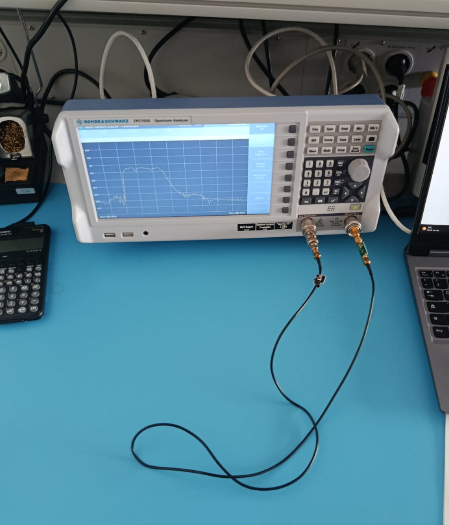

In [11]:
### Initialisiserung 
import json
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().resolve()))

from lib.plot_style import apply_lab_matplotlib_style

apply_lab_matplotlib_style()

from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass

FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 5.0
SCREENSHOT_TIMEOUT = 10.0
TRACE_READ_MAX_BYTES = 256 * 1024

REPLAY = False
REPLAY_FILE = Path("recordings") / "1-final-lab_replay.json"
SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_FILENAME = "screen.png"

In [12]:
from lib.replay_json import load_replay_json, save_replay_json
from lib.scpi_tcp import get_trace_data, scpi_query, screenshot_read, screenshot_save
from lib.mixer_plots import mixer_merge_save, plot_mixer_spectrum

print("Konfiguration:", FPC_IP, "Port", FPC_PORT)
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")


Konfiguration: 192.168.1.10 Port 5555
REPLAY=False, Datei=recordings\1-final-lab_replay.json


In [13]:
if REPLAY:
    try:
        replay = load_replay_json(REPLAY_FILE)
        idn_reply = replay.get("idn", "REPLAY")
        print("Gerät (Replay):", idn_reply)
    except FileNotFoundError:
        idn_reply = "REPLAY (keine Datei)"
        print("Replay-Datei noch nicht vorhanden — bitte später Live-Messungen ausführen.")
else:
    idn_reply = scpi_query(FPC_IP, FPC_PORT, "*IDN?", socket_timeout=SOCKET_TIMEOUT)
    print("Gerät:", idn_reply if idn_reply else "Keine Antwort (IP/Port prüfen?)")


Gerät: Rohde&Schwarz,FPC1500,1328.6660K03/206021,V1.90


In [14]:
Aufgabe

NameError: name 'Aufgabe' is not defined

In [17]:
key = "saw_filter_s11"
title = "Labor 9: S11 - Eingangsreflexion SAW Filter"

if REPLAY:
    data = load_replay_json(REPLAY_FILE)
    blk = data.get(key)
    if not blk:
        raise RuntimeError(f"Replay ohne {key} — Messung fehlt in {REPLAY_FILE}")
    freqs = blk["freqs_hz"]
    amps = blk["amps"]
    rbw_hz = blk.get("rbw_hz")
    print("Replay:", key, "—", len(amps), "Samples")
else:
    result = get_trace_data(
        FPC_IP,
        FPC_PORT,
        trace_read_max_bytes=TRACE_READ_MAX_BYTES,
        socket_timeout=SOCKET_TIMEOUT,
    )
    if result is None:
        raise RuntimeError("Keine Trace-Daten empfangen. Gerät im VNA-Modus?")
    freqs, amps, rbw_hz = result
    mixer_merge_save(
        key,
        freqs,
        amps,
        rbw_hz,
        idn_reply,
        replay_file=REPLAY_FILE,
    )

freq_hz = np.asarray(freqs, dtype=float)
p_db = np.asarray(amps, dtype=float)
plot_mixer_spectrum(
    freq_hz,
    p_db,
    rbw_hz,
    title,
    fig_id="s11_filter",
    replay=REPLAY,
    widgets_module=widgets,
    display_fn=display,
)

Replay gespeichert: C:\Users\danie\Desktop\FH Joanneum\ECE4\KT-course\lab_suite\labs\08_01_LABOR-9\submissions\recordings\1-final-lab_replay.json
  Spektren im File (Anzahl Samples): {'spectrum_lo': 0, 'spectrum_if': 0, 'spectrum_rf': 0}


Punkte: 201, f = 400.0000 … 500.0000 MHz


In [18]:
key = "saw_filter_s21"
title = "Labor 9: S21 - Transmission SAW Filter"

if REPLAY:
    data = load_replay_json(REPLAY_FILE)
    blk = data.get(key)
    if not blk:
        raise RuntimeError(f"Replay ohne {key} — Messung fehlt in {REPLAY_FILE}")
    freqs = blk["freqs_hz"]
    amps = blk["amps"]
    rbw_hz = blk.get("rbw_hz")
    print("Replay:", key, "—", len(amps), "Samples")
else:
    result = get_trace_data(
        FPC_IP,
        FPC_PORT,
        trace_read_max_bytes=TRACE_READ_MAX_BYTES,
        socket_timeout=SOCKET_TIMEOUT,
    )
    if result is None:
        raise RuntimeError("Keine Trace-Daten empfangen. Verkabelung (Port 1 & 2) prüfen!")
    freqs, amps, rbw_hz = result
    mixer_merge_save(
        key,
        freqs,
        amps,
        rbw_hz,
        idn_reply,
        replay_file=REPLAY_FILE,
    )

freq_hz = np.asarray(freqs, dtype=float)
p_db = np.asarray(amps, dtype=float)
plot_mixer_spectrum(
    freq_hz,
    p_db,
    rbw_hz,
    title,
    fig_id="s21_filter",
    replay=REPLAY,
    widgets_module=widgets,
    display_fn=display,
)

Replay gespeichert: C:\Users\danie\Desktop\FH Joanneum\ECE4\KT-course\lab_suite\labs\08_01_LABOR-9\submissions\recordings\1-final-lab_replay.json
  Spektren im File (Anzahl Samples): {'spectrum_lo': 0, 'spectrum_if': 0, 'spectrum_rf': 0}


Punkte: 201, f = 400.0000 … 500.0000 MHz
